# Thick-Walled Cylinder — v2 (loads composite)

Same Lamé problem as `example_plate_pyGmsh.ipynb`, rewritten on top of the
`g.loads` composite. The key change: the manual *consistent nodal force*
loop on the inner arc is gone. Pressure is declared **before meshing** as

```python
g.loads.line(pg='Pressure', magnitude=p, normal=True)
```

The composite reads the curve's orientation from the surface boundary
loop (`gmsh.model.getBoundary`), computes the per-edge in-plane normal
from the chord tangent, and lumps `p · n_out · L/2` to each endpoint.
Convention: positive `magnitude` pushes into the structure.

Everything else (geometry, ops model build, analysis, post-processing) is
deliberately the same as v1 so the diff is the load step.

In [1]:
import numpy as np
import openseespy.opensees as ops
from apeGmsh import apeGmsh

# Lamé problem — quarter annulus, plane strain
inner_radius = 100.0   # mm
outer_radius = 200.0   # mm
lc           = 10.0    # mm
E            = 210.0e3 # MPa
nu           = 0.3
p            = 100.0   # MPa internal pressure
thk          = 1.0     # plane strain unit thickness

## 1. Geometry & physical groups

Identical to v1 — quarter-annulus from 4 points, 2 lines, 2 arcs.

In [2]:
g = apeGmsh(model_name='Plate2D_v2', verbose=True)
g.begin()

pc = g.model.geometry.add_point(0, 0, 0, lc=lc, label='center')
p1 = g.model.geometry.add_point(inner_radius, 0, 0, lc=lc, label='inner_x')
p2 = g.model.geometry.add_point(outer_radius, 0, 0, lc=lc, label='outer_x')
p3 = g.model.geometry.add_point(0, outer_radius, 0, lc=lc, label='outer_y')
p4 = g.model.geometry.add_point(0, inner_radius, 0, lc=lc, label='inner_y')

l1 = g.model.geometry.add_line(p1, p2, label='bottom')
l2 = g.model.geometry.add_arc(p2, pc, p3, label='outer_arc')
l3 = g.model.geometry.add_line(p3, p4, label='left')
l4 = g.model.geometry.add_arc(p4, pc, p1, label='inner_arc')

loop = g.model.geometry.add_curve_loop([l1, l2, l3, l4])
surf = g.model.geometry.add_plane_surface(loop, label='plate')

g.physical.add(1, [l1], name='Sym_Y')
g.physical.add(1, [l3], name='Sym_X')
g.physical.add(1, [l4], name='Pressure')
g.physical.add(2, [surf], name='Plate')

Gmsh version: 4.15.1


[Model] add_point(0, 0, 0) -> tag 1
[Labels] add('center', dim=0, tags=[1]) -> pg_tag=1
[Model] add_point(100.0, 0, 0) -> tag 2
[Labels] add('inner_x', dim=0, tags=[2]) -> pg_tag=2
[Model] add_point(200.0, 0, 0) -> tag 3
[Labels] add('outer_x', dim=0, tags=[3]) -> pg_tag=3
[Model] add_point(0, 200.0, 0) -> tag 4
[Labels] add('outer_y', dim=0, tags=[4]) -> pg_tag=4
[Model] add_point(0, 100.0, 0) -> tag 5
[Labels] add('inner_y', dim=0, tags=[5]) -> pg_tag=5
[Model] add_line(2 -> 3) -> tag 1
[Labels] add('bottom', dim=1, tags=[1]) -> pg_tag=6
[Model] add_arc(start=3, centre=1, end=4) -> tag 2
[Labels] add('outer_arc', dim=1, tags=[2]) -> pg_tag=7
[Model] add_line(4 -> 5) -> tag 3
[Labels] add('left', dim=1, tags=[3]) -> pg_tag=8
[Model] add_arc(start=5, centre=1, end=2) -> tag 4
[Labels] add('inner_arc', dim=1, tags=[4]) -> pg_tag=9
[Model] add_curve_loop([1, 2, 3, 4]) -> tag 1
[Model] add_plane_surface(wires=[1]) -> tag 1
[Labels] add('plate', dim=2, tags=[1]) -> pg_tag=10
[PhysicalGroup

14

## 2. Declare the pressure load (before meshing)

`normal=True` makes the line load act perpendicular to each edge. The
composite asks Gmsh which surface the curve bounds and uses the loop
orientation to pick the side; no `away_from=` reference point needed in
this case (the inner arc bounds exactly one surface). For ambiguous
interior interfaces or curves with no adjacent surface, pass
`away_from=(x0, y0, z0)` to disambiguate manually.

Resolution mode `'tributary'` (default) lumps `p · L/2 · n` to each
endpoint; `'consistent'` does shape-function integration (matters only
for higher-order edges).

In [3]:
g.loads.line(pg='Pressure', magnitude=p, normal=True)
g.loads.summary()

,kind,name,pattern,target,source,reduction,target_form,params
0,line,,default,Pressure,pg,tributary,nodal,"magnitude=100.0, direction=(0.0, 0.0, -1.0), n..."


## 3. Mesh + FEMData snapshot

`renumber(method='rcm')` is needed before `get_fem_data` so OpenSees gets
dense 1-based IDs with reduced bandwidth. The `fem` object now carries
the resolved load records on `fem.nodes.loads`.

In [4]:
g.mesh.generation.set_order(1)
g.mesh.generation.generate(2)
g.mesh.partitioning.renumber(dim=2, method='rcm', base=1)

# remove_orphans=True drops the OCC arc-center node (no element references it).
fem = g.mesh.queries.get_fem_data(dim=2, remove_orphans=True)
print(fem.inspect.summary())

1 orphan node(s) removed (not connected to any element). First: [331 (0, 0, 0)]


[Mesh] set_order(1)
[Mesh] generate(dim=2)
[Mesh] renumber(method='rcm', dim=2): 331 nodes, 590 elements, bw 314→24
[Mesh] get_fem_data(dim=2) -> 330 nodes, 590 elements, bw=24
330 nodes, 590 elements (tri3:590), bandwidth=24
  Physical groups (4):
    (1) "Sym_Y"                  11 nodes, 10 elems
    (1) "Sym_X"                  11 nodes, 10 elems
    (1) "Pressure"               17 nodes, 16 elems
    (2) "Plate"                  330 nodes, 590 elems
  Labels (10):
    (0) 'center'                 1 nodes
    (0) 'inner_x'                1 nodes
    (0) 'outer_x'                1 nodes
    (0) 'outer_y'                1 nodes
    (0) 'inner_y'                1 nodes
    (1) 'bottom'                 11 nodes, 10 elems
    (1) 'outer_arc'              33 nodes, 32 elems
    (1) 'left'                   11 nodes, 10 elems
    (1) 'inner_arc'              17 nodes, 16 elems
    (2) 'plate'                  330 nodes, 590 elems
  Element types (1):
    tri3         dim=2, order=1, npe=3

In [5]:
# Sanity check — total resultant should match the analytical Lamé
# resultant on a quarter arc: p * R_i in each cartesian component.
fx_tot = sum((ld.force_xyz or (0, 0, 0))[0] for ld in fem.nodes.loads)
fy_tot = sum((ld.force_xyz or (0, 0, 0))[1] for ld in fem.nodes.loads)
print(f'Sum F = ({fx_tot:.3f}, {fy_tot:.3f})  (expected {p*inner_radius:.3f}, {p*inner_radius:.3f})')

Sum F = (10000.000, 10000.000)  (expected 10000.000, 10000.000)


## 4. Build the OpenSees model

Selecting nodes via `fem.nodes.get(pg='Plate')` filters the orphan node
left over from the OCC arc-center point — it has no element attachment
and would otherwise leave free DOFs in the system. Nodes in `Sym_X` /
`Sym_Y` come from the same composite-driven selection.

In [6]:
ops.wipe()
ops.model('basic', '-ndm', 2, '-ndf', 2)

# Nodes — orphans already filtered out by remove_orphans=True
for nid, xyz in zip(fem.nodes.ids, fem.nodes.coords):
    ops.node(int(nid), float(xyz[0]), float(xyz[1]))

# Material + tri31 elements (connectivity already in solver IDs)
ops.nDMaterial('ElasticIsotropic', 1, E, nu)
for eid, conn in zip(fem.elements.ids, fem.elements.connectivity):
    ops.element('tri31', int(eid), *(int(n) for n in conn), thk, 'PlaneStrain', 1)

# Symmetry BCs — direct nodal SP from physical-group selection
for nid in fem.nodes.get_ids(pg='Sym_Y'):
    ops.fix(int(nid), 0, 1)   # uy = 0 on bottom
for nid in fem.nodes.get_ids(pg='Sym_X'):
    ops.fix(int(nid), 1, 0)   # ux = 0 on left

Tri31 - Written by Roozbeh G. Mikola and N.Sitar, UC Berkeley


## 5. Apply loads — straight from `fem.nodes.loads`

Compare with v1, where this section was ~30 lines of manual edge-by-edge
consistent force integration. The composite already did that work.

In [7]:
ops.timeSeries('Linear', 1)
ops.pattern('Plain', 1, 1)
for ld in fem.nodes.loads:
    fx, fy, _ = ld.force_xyz or (0.0, 0.0, 0.0)
    ops.load(int(ld.node_id), fx, fy)
print(f'Applied {len(fem.nodes.loads)} nodal loads')

Applied 17 nodal loads


## 6. Analysis

In [8]:
ops.constraints('Transformation')
ops.numberer('RCM')
ops.system('BandGeneral')
ops.test('NormDispIncr', 1e-8, 10)
ops.algorithm('Newton')
ops.integrator('LoadControl', 1.0)
ops.analysis('Static')
ok = ops.analyze(1)
print('CONVERGED' if ok == 0 else f'FAILED ({ok})')

CONVERGED


## 7. Post-processing — radial displacement & σ_xx

Standard FEM post-processing on the Plate PG node set so the orphan node
stays out of the arrays.

In [9]:
node_ids     = fem.nodes.ids
node_coords  = fem.nodes.coords
elem_ids     = fem.elements.ids
connectivity = fem.elements.connectivity
nNode = len(node_ids)
nElem = len(elem_ids)

# Solver ID -> array index
id_to_idx = {int(nid): i for i, nid in enumerate(node_ids)}

# Displacements
disp = np.zeros((nNode, 2))
for i, nid in enumerate(node_ids):
    disp[i, 0] = ops.nodeDisp(int(nid), 1)
    disp[i, 1] = ops.nodeDisp(int(nid), 2)

# Radial displacement: u_r = (x ux + y uy) / r
r_nodes = np.sqrt(node_coords[:, 0]**2 + node_coords[:, 1]**2)
r_safe  = np.where(r_nodes > 1e-12, r_nodes, 1.0)
ur = (node_coords[:, 0]*disp[:, 0] + node_coords[:, 1]*disp[:, 1]) / r_safe

# Element-constant stresses (tri31 / CST)
sig_xx = np.zeros(nElem); sig_yy = np.zeros(nElem); sig_xy = np.zeros(nElem)
for i, eid in enumerate(elem_ids):
    s = ops.eleResponse(int(eid), 'stresses')
    sig_xx[i] = s[0]; sig_yy[i] = s[1]; sig_xy[i] = s[2]

# Nodal-averaged sig_xx (smooth contour)
conn_idx = np.array([[id_to_idx[int(n)] for n in row] for row in connectivity])
sig_xx_nodal = np.zeros(nNode); count = np.zeros(nNode)
for e in range(nElem):
    for ln in range(3):
        sig_xx_nodal[conn_idx[e, ln]] += sig_xx[e]
        count[conn_idx[e, ln]] += 1.0
count[count == 0] = 1.0
sig_xx_nodal /= count

print(f'u_r  range: [{ur.min():.6f}, {ur.max():.6f}] mm')
print(f'sig_xx range: [{sig_xx.min():.2f}, {sig_xx.max():.2f}] MPa')
ops.wipe()

u_r  range: [0.057395, 0.090482] mm
sig_xx range: [-101.87, 174.57] MPa


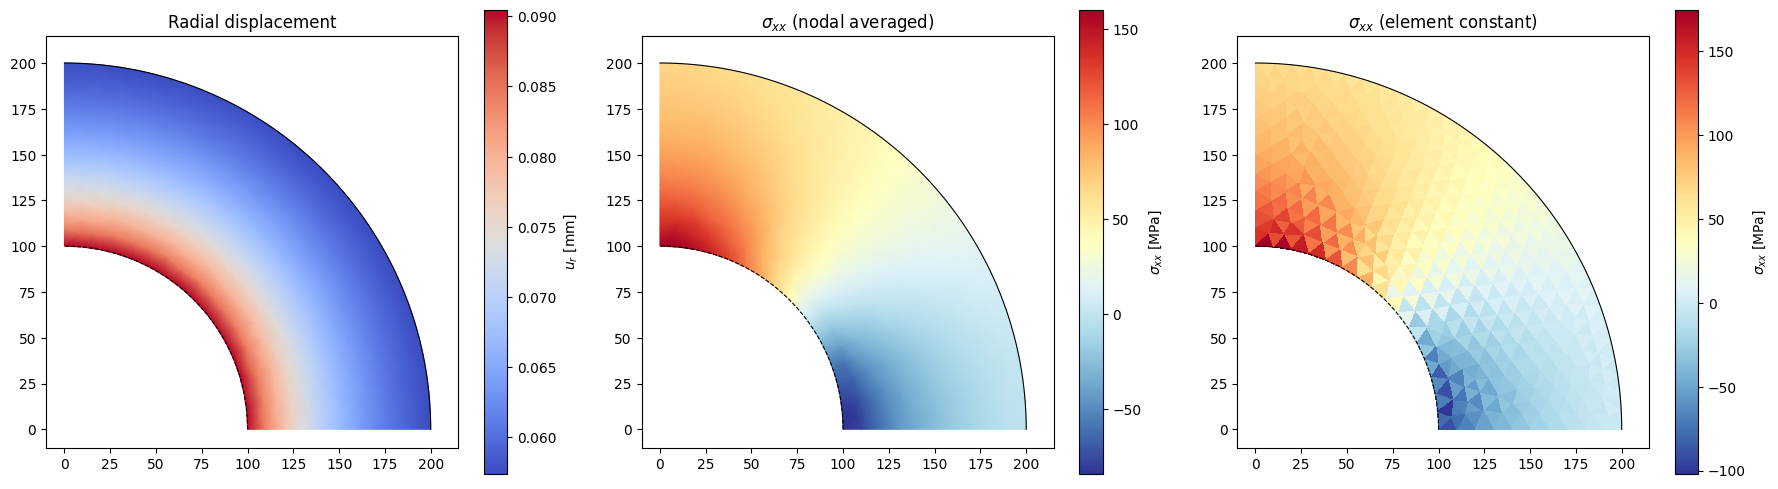

In [10]:
import matplotlib.pyplot as plt
import matplotlib.tri as mtri

triang = mtri.Triangulation(node_coords[:, 0], node_coords[:, 1], conn_idx)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

tp1 = axes[0].tripcolor(triang, ur, shading='gouraud', cmap='coolwarm')
plt.colorbar(tp1, ax=axes[0], label=r'$u_r$ [mm]')
axes[0].set_title('Radial displacement')

tp2 = axes[1].tripcolor(triang, sig_xx_nodal, shading='gouraud', cmap='RdYlBu_r')
plt.colorbar(tp2, ax=axes[1], label=r'$\sigma_{xx}$ [MPa]')
axes[1].set_title(r'$\sigma_{xx}$ (nodal averaged)')

tp3 = axes[2].tripcolor(triang, sig_xx, shading='flat', cmap='RdYlBu_r')
plt.colorbar(tp3, ax=axes[2], label=r'$\sigma_{xx}$ [MPa]')
axes[2].set_title(r'$\sigma_{xx}$ (element constant)')

theta = np.linspace(0, np.pi/2, 100)
for ax in axes:
    ax.plot(inner_radius*np.cos(theta), inner_radius*np.sin(theta), 'k--', lw=0.8)
    ax.plot(outer_radius*np.cos(theta), outer_radius*np.sin(theta), 'k-',  lw=0.8)
    ax.set_aspect('equal'); ax.set_xlim(-10, outer_radius+15); ax.set_ylim(-10, outer_radius+15)

plt.tight_layout(); plt.show()

## 8. Verification against the Lamé closed form

Plane strain: substitute `E* = E/(1-nu^2)` and `nu* = nu/(1-nu)`. The
radial displacement on a thick-walled cylinder under internal pressure
`p_i` is

$$u_r(r) = \frac{p_i\,R_i^2}{E^*\,(R_o^2 - R_i^2)}\left[(1-\nu^*)\,r + (1+\nu^*)\,\frac{R_o^2}{r}\right]$$

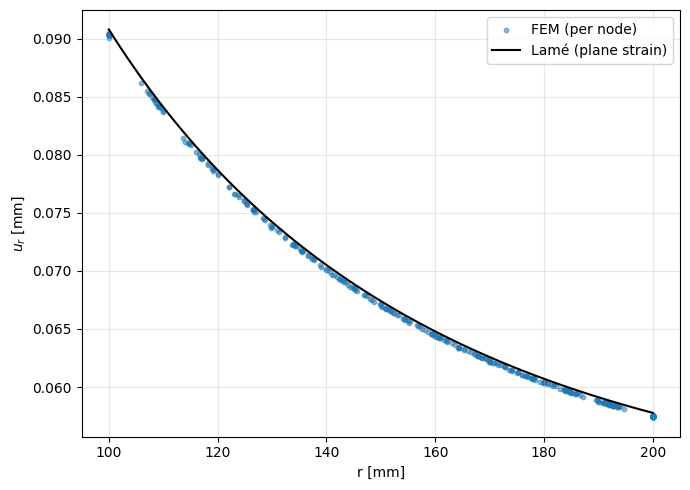

In [11]:
Es  = E / (1 - nu**2)
nus = nu / (1 - nu)
A   = (p * inner_radius**2) / (outer_radius**2 - inner_radius**2)
ur_an = (A / Es) * ((1 - nus) * r_nodes + (1 + nus) * outer_radius**2 / r_safe)

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(r_nodes, ur, s=10, alpha=0.5, label='FEM (per node)')
rr = np.linspace(inner_radius, outer_radius, 100)
ax.plot(rr, (A/Es)*((1-nus)*rr + (1+nus)*outer_radius**2/rr), 'k-', lw=1.5, label='Lamé (plane strain)')
ax.set_xlabel('r [mm]'); ax.set_ylabel(r'$u_r$ [mm]')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 9b. Re-run with `Recorders` + `DomainCapture` (integrated path)

The snippet above is a *post-hoc* snapshot — it works because we've
stashed `disp` and `sig_xx_nodal` in numpy arrays before `ops.wipe()`.
The native pattern for production analyses is the **declarative
`Recorders` DSL + `DomainCapture` context manager**: you list which
fields you want, the capture wires `ops.nodeDisp` / `ops.nodeReaction`
/ `ops.eleResponse` reads behind the scenes, and the analysis loop
calls `cap.step(t=...)` after each `ops.analyze(...)`.

It rebuilds the OpenSees model + reruns the static solve under
the capture context, then opens that h5 in another viewer subprocess.
Compare the two paths: the manual one is fine for a one-step snapshot,
but the DomainCapture pattern scales to multi-stage transient runs
with multiple recorders without you having to manage the buffers.

In [ ]:
from apeGmsh.solvers.Recorders import Recorders
from apeGmsh.results.capture._domain import DomainCapture

# Declare what to capture (FEMData-aware selectors).
recs = Recorders()
recs.nodes(components='displacement', pg='Plate')
recs.nodes(components='reaction_force', pg='Plate')
spec = recs.resolve(fem, ndm=2, ndf=2)

# Rebuild the OpenSees model so capture can drive ops.analyze.
ops.wipe()
ops.model('basic', '-ndm', 2, '-ndf', 2)
for nid, xyz in zip(fem.nodes.ids, fem.nodes.coords):
    ops.node(int(nid), float(xyz[0]), float(xyz[1]))
ops.nDMaterial('ElasticIsotropic', 1, E, nu)
for eid, conn in zip(fem.elements.ids, fem.elements.connectivity):
    ops.element('tri31', int(eid), *(int(n) for n in conn), thk, 'PlaneStrain', 1)
for nid in fem.nodes.get_ids(pg='Sym_Y'):
    ops.fix(int(nid), 0, 1)
for nid in fem.nodes.get_ids(pg='Sym_X'):
    ops.fix(int(nid), 1, 0)
ops.timeSeries('Linear', 1)
ops.pattern('Plain', 1, 1)
for ld in fem.nodes.loads:
    fx, fy, _ = ld.force_xyz or (0.0, 0.0, 0.0)
    ops.load(int(ld.node_id), fx, fy)
ops.constraints('Transformation')
ops.numberer('RCM')
ops.system('BandGeneral')
ops.test('NormDispIncr', 1e-8, 10)
ops.algorithm('Newton')
ops.integrator('LoadControl', 1.0)
ops.analysis('Static')

from apeGmsh import workdir
OUT = workdir()
capture_path = OUT / 'capture.h5'
if capture_path.exists():
    capture_path.unlink()

with DomainCapture(spec, capture_path, fem, ndm=2, ndf=2) as cap:
    cap.begin_stage('static', kind='static')
    ok = ops.analyze(1)
    if ok != 0:
        raise RuntimeError(f'analyze failed ({ok})')
    cap.step(t=ops.getTime())
    cap.end_stage()

ops.wipe()
print(f'Captured -> {capture_path} ({capture_path.stat().st_size / 1024:.1f} KB)')

In [ ]:
# Open the captured run in another viewer subprocess.
results_cap = Results.from_native(capture_path)
handle_cap = results_cap.viewer(blocking=False)
print(f'Viewer subprocess pid: {handle_cap.pid}  -- close the window to exit.')

In [12]:
g.end()

## 10. Diff vs v1

| Step | v1 | v2 |
|---|---|---|
| Apply pressure | ~30 lines: per-edge length, traction `t = p·n̂`, `(L/6)(2tᵢ+tⱼ)` lumping, `nodal_forces.setdefault` accumulator | `g.loads.line(pg='Pressure', magnitude=p, normal=True)` (pre-mesh) + `for ld in fem.nodes.loads: ops.load(...)` (post-mesh) |
| Edge connectivity query | `g.mesh.queries.get_elements(dim=1, tag=l4)` | none — composite resolves the target |
| Direction handling | inline cartesian computation per node | declarative `normal=True`; sign from Gmsh boundary loop |
| Total resultant verification | implicit | explicit one-liner over `fem.nodes.loads` |

The accuracy is identical because the underlying lumping math is the
same — the composite just owns it now.